In [ ]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy

In [ ]:
def calculate_orbit_vectors(e, a, q, i, node, peri, fs):
    deg = np.pi/180
    i = i * deg
    node = node * deg
    peri = peri * deg
    
    Rz_omega = spy.rotate(peri, 3)
    Rx_i = spy.rotate(i, 1)
    Rz_Omega = spy.rotate(node, 3)

    M_astro2perifocal = Rz_omega @ Rx_i @ Rz_Omega
    M_perifocal2astro = M_astro2perifocal.T

    p = q * (1 + e) # q is in AU
    rs = p / (1 + e*np.cos(fs))

    xfs = rs * np.cos(fs)
    yfs = rs * np.sin(fs)
    zfs = np.zeros_like(xfs)

    rvecs = (M_perifocal2astro @ np.array([xfs, yfs, zfs])).T

    return rvecs, xfs, yfs, zfs, M_perifocal2astro

In [ ]:
fs = np.linspace(0, 2*np.pi, 100)

e_apophis = 0.1911663355386932 
a_apophis = 0.9223803173917017 
q_apophis = 0.7460522521429133 
i_apophis = 3.340958441017069
node_apophis = 203.8996515621043
peri_apophis = 126.6728325163065

rvecs_asteroid, xfs_asteroid, yfs_asteroid, zfs_asteroid, M_asteroid_p2a = calculate_orbit_vectors(e_apophis, a_apophis, q_apophis, i_apophis, node_apophis, peri_apophis, fs)

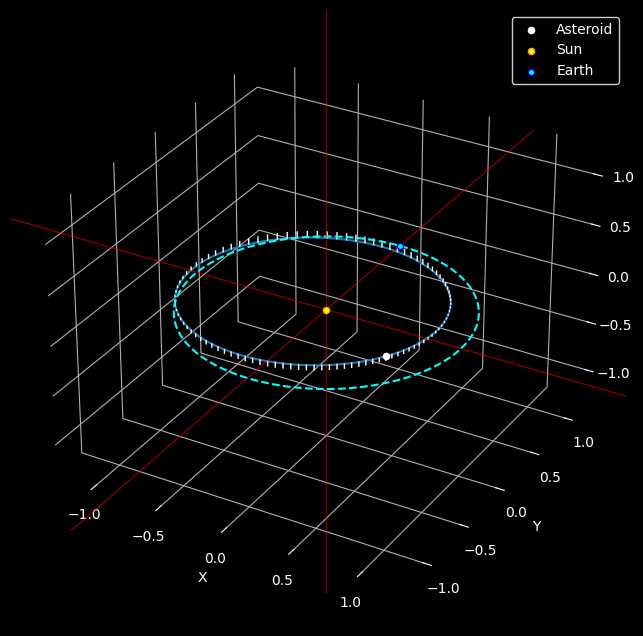

In [ ]:
fs = np.linspace(0, 2*np.pi, 100)

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111, projection="3d")

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)) 
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)) 
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)) 
#ax.grid(False)

ax.set_facecolor("black")
fig.set_facecolor("black")

# Asteroid
rvecs = (M_asteroid_p2a @ np.array([xfs_asteroid, yfs_asteroid, zfs_asteroid])).T
ax.plot(rvecs[:,0], rvecs[:,1], rvecs[:,2])
ax.scatter(rvecs[0,0], rvecs[0,1], rvecs[0,2], color="white", label= "Asteroid")
# Lil lines
for i in range(0, len(rvecs_asteroid)):
  ax.plot([rvecs_asteroid[i, 0], rvecs_asteroid[i, 0]], [rvecs_asteroid[i, 1], rvecs_asteroid[i, 1]], [0, rvecs_asteroid[i, 2]], color="white", linestyle="-", linewidth=1)

# Sun !!
ax.scatter(0, 0, 0, color="yellow", marker="o", edgecolors="orange", label = "Sun")

# Earth 
ax.plot(np.cos(fs), np.sin(fs), 0, color="cyan", linestyle="--")
ax.scatter(0, 1, 0, color="cyan", marker="o", edgecolors="blue", label = "Earth")

# Axis (from the origin)
axis_len = 3
ax.plot([-axis_len, axis_len], [0, 0], [0, 0], color="red", alpha=0.5, linewidth=1)
ax.plot([0, 0], [-axis_len, axis_len], [0, 0], color="red", alpha=0.5, linewidth=1)
ax.plot([0, 0], [0, 0], [-axis_len, axis_len], color="red", alpha=0.5, linewidth=1)

# Axis limits
axis_lim = 1.3
ax.set_xlim(-axis_lim, axis_lim) 
ax.set_ylim(-axis_lim, axis_lim)
ax.set_zlim(-axis_lim, axis_lim)

ax.set_xlabel("X (AU)", color="white")
ax.set_ylabel("Y (AU)", color="white")
ax.set_zlabel("Z (AU)", color="white")
ax.tick_params(colors='white')

plt.legend(facecolor="black", edgecolor="white", labelcolor="white")
plt.show()